# V0 Variants Comparison

Ablation study comparing V0 baseline with incremental prompt additions.

## Prompt Components

- **V0 (baseline)**: Minimal zero-shot prompt — only the definition of Visual Complexity (0–1 scale). Model returns a single `vc_score` plus a brief explanation.
- **T (Topics, i.e. 7 complexity dimensions)**: Adds 7 dimensions (data density, visual encoding, semantics/text, schema, color/symbol, aesthetics, cognitive load) as mental checkpoints. Model still produces a single holistic `vc_score` — no per-dimension scores required. *(Named "topics" in the prompt; not to be confused with topic modeling elsewhere in the project.)*
- **C (Calibration)**: Adds scale anchoring guidance with example chart types mapped to approximate score ranges (plain bar chart ≈ 0.25–0.40, standard scatterplot ≈ 0.45–0.60, dense multi-panel ≈ 0.85–0.95). Instructs the model to use the full range and push scores up when uncertain. *(Note: the guidance only covers 0.25–0.95; the 0.0–0.25 region is left undefined.)*
- **A (Anchors)**: Prepends 3 labeled example images (vc_score = 0.22, 0.54, 0.95) as few-shot in-context references before the target image. Same minimal system prompt as V0.
- **W (Weighted)**: Adds qualitative weight guidance over the 7 topics — high weight on density/encoding/schema/cognitive, medium on color/aesthetic, low on text. In this study W is only paired with TCA.

## Variant Combinations

| Variant | Topics | Calibration | Anchors | Weighted |
|---------|--------|-------------|---------|---------|
| V0      | ✗ | ✗ | ✗ | ✗ |
| V0+T    | ✓ | ✗ | ✗ | ✗ |
| V0+C    | ✗ | ✓ | ✗ | ✗ |
| V0+A    | ✗ | ✗ | ✓ | ✗ |
| V0+TC   | ✓ | ✓ | ✗ | ✗ |
| V0+TA   | ✓ | ✗ | ✓ | ✗ |
| V0+CA   | ✗ | ✓ | ✓ | ✗ |
| V0+TCA  | ✓ | ✓ | ✓ | ✗ |
| V0+TWCA| ✓ | ✓ | ✓ | ✓ |

## Runs

r1/r2 are **deterministic** (`temperature=0`); r3/r4 use Claude's **extended/adaptive thinking** (no `budget_tokens`, temperature unset → stochastic).

| Run | Config | Model | Variants |
|-----|--------|-------|----------|
| r1  | temperature=0 | opus-4.6 | all 9 |
| r2  | temperature=0 (duplicate of r1) | opus-4.6 | all 9 |
| r3a | adaptive thinking | opus-4.6 | V0, V0+T, V0+TCA, V0+TWCA |
| r3b | adaptive thinking | **sonnet-4.6** | V0+TC, V0+TA, V0+CA |
| r4  | adaptive thinking | opus-4.6 | V0+TC, V0+TA, V0+CA, V0+TWCA |

*r3b used sonnet-4.6 for TC/TA/CA (initial run); r4 re-runs those same three variants on opus-4.6 for cross-variant parity within the thinking condition. r4 also includes V0+TWCA.*

## Evaluation Set

All metrics are computed on **43 images** — the full 46-image ground-truth set minus the 3 anchor images (`VisC.503.6.png`, `InfoVisJ.619.17.png`, `InfoVisJ.1149.6(1).png`), which are used as few-shot examples in V0+A / V0+TA / V0+CA / V0+TCA / V0+TWCA and therefore excluded from all variants' evaluation for a fair comparison.

## Headline Metric — CCC (Lin's Concordance Correlation Coefficient)

We report **CCC** as the primary agreement metric. CCC measures how tightly `(gt, pred)` points cluster around the **identity line** $\hat{y}=y$, jointly penalizing (1) low correlation, (2) mean bias, and (3) scale mismatch. Unlike sklearn's R² it is bounded in [−1, 1] and stable at small n; unlike Pearson it is not invariant to shift/rescale, so it rewards predictions that are *actually close* to the human ground truth rather than merely monotonically related. Spearman (rank-only) and Pearson (precision-only) and MAE/RMSE are kept as diagnostics in the full stats table below.

### CCC Summary (higher = better)

`det_avg` = mean of r1 and r2 (deterministic, `t=0`). `think_avg` = mean of r3 and r4 (adaptive thinking).

| variant  | r1    | r2    | **det_avg** | r3    | r4    | **think_avg** |
|----------|-------|-------|-------------|-------|-------|---------------|
| V0       | 0.858 | 0.859 | **0.858**   | 0.868 | 0.881 | **0.875**     |
| V0+T     | 0.871 | 0.867 | **0.869**   | 0.857 | —     | **0.857**     |
| V0+C     | 0.851 | 0.856 | **0.854**   | —     | —     | —             |
| V0+A     | 0.852 | 0.853 | **0.852**   | —     | —     | —             |
| V0+TC    | 0.854 | —     | **0.854**   | 0.737 | 0.866 | **0.802**     |
| V0+TA    | 0.860 | —     | **0.860**   | 0.849 | 0.834 | **0.841**     |
| V0+CA    | 0.852 | —     | **0.852**   | 0.831 | 0.873 | **0.852**     |
| V0+TCA   | 0.856 | 0.856 | **0.856**   | 0.874 | 0.873 | **0.874**     |
| V0+TWCA | 0.868 | 0.871 | **0.869**   | 0.811 | 0.815 | **0.813**     |

### Observations

- **Deterministic results are tightly bunched** (det_avg ∈ 0.852–0.869). At `t=0`, the ablation components do not meaningfully distinguish variants — all prompts land within ≈0.02 CCC of each other.
- **V0+T and V0+TWCA tie for the best deterministic score** (both 0.869), narrowly ahead of the baseline V0 (0.858).
- **Adaptive thinking helps the lightest prompts**: V0 improves 0.858 → 0.875 and V0+TCA improves 0.856 → 0.874 when switching from `t=0` to thinking.
- **Adaptive thinking *hurts* V0+TWCA** (0.869 → 0.813). The qualitative weight guidance appears to interact poorly with extended reasoning — the model may be over-applying the "down-weight text" instruction when given more tokens to deliberate.
- **r3 sonnet-4.6 run for V0+TC is a clear outlier** (0.737); the r4 opus-4.6 re-run recovers to 0.866, confirming it was a model-capacity effect rather than a prompt defect.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr, spearmanr

ROOT = Path('..').resolve()
GT_CSV = ROOT / 'Claude_vc_prediction' / 'gt_all_46.csv'

VARIANT_BASES = {
    'V0':       'results/vc_api_46gt_v0',
    'V0+T':     'results/vc_api_46gt_v0_topic',
    'V0+C':     'results/vc_api_46gt_v0_calibration',
    'V0+A':     'results/vc_api_46gt_v0_anchors',
    'V0+TC':    'results/vc_api_46gt_v0_tc',
    'V0+TA':    'results/vc_api_46gt_v0_ta',
    'V0+TW':    'results/vc_api_46gt_v0_tw',
    'V0+TWC':   'results/vc_api_46gt_v0_twc',
    'V0+TWA':   'results/vc_api_46gt_v0_twa',
    'V0+TWdet': 'results/vc_api_46gt_v0_tw_det',
    'V0+CA':    'results/vc_api_46gt_v0_ca',
    'V0+TCA':   'results/vc_api_46gt_v0_tca',
    'V0+TWCA': 'results/vc_api_46gt_v0_tcaw',
}

# Anchor images used as few-shot examples — excluded from evaluation plots
ANCHOR_IMAGES = {'VisC.503.6.png', 'InfoVisJ.619.17.png', 'InfoVisJ.1149.6(1).png'}

# r1: temperature=0  |  r3/r4: adaptive thinking
RUNS = {
    'r1': lambda base: ROOT / base          / 'vc_scores.csv',
    'r2': lambda base: ROOT / f'{base}_r2'  / 'vc_scores.csv',
    'r3': lambda base: ROOT / f'{base}_r3'  / 'vc_scores.csv',
    'r4': lambda base: ROOT / f'{base}_r4'  / 'vc_scores.csv',
}

# Model used per (run, variant). Default is opus-4.6; exceptions listed below.
_SONNET_RUNS = {('r3', 'V0+TC'), ('r3', 'V0+TA'), ('r3', 'V0+CA')}

def get_run_model(run, variant):
    return 'sonnet-4.6' if (run, variant) in _SONNET_RUNS else 'opus-4.6'

VARIANTS_BY_RUN = {
    run: {name: fn(base) for name, base in VARIANT_BASES.items()}
    for run, fn in RUNS.items()
}

gt = pd.read_csv(GT_CSV).rename(columns={'imageName': 'filename', 'NormalizedVC': 'gt'})
gt = gt[['filename', 'gt']]
print(f'GT rows (all): {len(gt)}')
gt_eval = gt[~gt['filename'].isin(ANCHOR_IMAGES)].reset_index(drop=True)
print(f'GT rows (excl. anchors): {len(gt_eval)}\n')

header = f"{'variant':<12}" + ''.join(f'{r:>6}' for r in RUNS)
print(header)
for name, base in VARIANT_BASES.items():
    avail = ''.join('  ✓' if VARIANTS_BY_RUN[r][name].exists() else '  ✗' for r in RUNS)
    print(f'{name:<12}{avail}')


GT rows (all): 46
GT rows (excl. anchors): 43

variant         r1    r2    r3    r4
V0            ✓  ✓  ✓  ✓
V0+T          ✓  ✓  ✓  ✗
V0+C          ✓  ✓  ✗  ✗
V0+A          ✓  ✓  ✗  ✗
V0+TC         ✓  ✗  ✓  ✓
V0+TA         ✓  ✗  ✓  ✓
V0+TW         ✓  ✓  ✗  ✗
V0+TWC        ✓  ✓  ✗  ✗
V0+TWA        ✓  ✓  ✗  ✗
V0+TWdet      ✓  ✓  ✗  ✗
V0+CA         ✓  ✗  ✓  ✓
V0+TCA        ✓  ✓  ✓  ✓
V0+TWCA       ✓  ✓  ✓  ✓


In [3]:
def load_merged(variants_dict, base_gt):
    merged = base_gt.copy()
    for name, path in variants_dict.items():
        if not path.exists():
            continue
        df = pd.read_csv(path)[['filename', 'vc_score']].rename(columns={'vc_score': name})
        merged = merged.merge(df, on='filename', how='left')
    return merged

# Use gt_eval (43 images, anchors excluded) for all analysis
merged_by_run = {run: load_merged(VARIANTS_BY_RUN[run], gt_eval) for run in RUNS}

for run, m in merged_by_run.items():
    loaded = [n for n in VARIANT_BASES if n in m.columns]
    print(f'{run}: {len(loaded)} variants loaded — {loaded}')


r1: 13 variants loaded — ['V0', 'V0+T', 'V0+C', 'V0+A', 'V0+TC', 'V0+TA', 'V0+TW', 'V0+TWC', 'V0+TWA', 'V0+TWdet', 'V0+CA', 'V0+TCA', 'V0+TWCA']
r2: 10 variants loaded — ['V0', 'V0+T', 'V0+C', 'V0+A', 'V0+TW', 'V0+TWC', 'V0+TWA', 'V0+TWdet', 'V0+TCA', 'V0+TWCA']
r3: 7 variants loaded — ['V0', 'V0+T', 'V0+TC', 'V0+TA', 'V0+CA', 'V0+TCA', 'V0+TWCA']
r4: 6 variants loaded — ['V0', 'V0+TC', 'V0+TA', 'V0+CA', 'V0+TCA', 'V0+TWCA']


In [4]:
def concordance_cc(y, yhat):
    """Lin's Concordance Correlation Coefficient: agreement with the identity line."""
    y, yhat = np.asarray(y, dtype=float), np.asarray(yhat, dtype=float)
    my, mh = y.mean(), yhat.mean()
    vy, vh = y.var(), yhat.var()
    cov = ((y - my) * (yhat - mh)).mean()
    denom = vy + vh + (my - mh) ** 2
    return 2 * cov / denom if denom > 0 else np.nan


def compute_stats(merged, run_label):
    rows = []
    for name in VARIANT_BASES:
        if name not in merged.columns:
            continue
        sub = merged[['gt', name]].dropna()
        if len(sub) == 0:
            continue
        y, yhat = sub['gt'].values, sub[name].values
        rows.append({
            'run':      run_label,
            'variant':  name,
            'n':        len(sub),
            'CCC':      concordance_cc(y, yhat),
            'Spearman': spearmanr(y, yhat)[0],
            'Pearson':  pearsonr(y, yhat)[0],
            'R2':       r2_score(y, yhat),
            'MAE':      mean_absolute_error(y, yhat),
            'RMSE':     np.sqrt(mean_squared_error(y, yhat)),
            'mean_pred': yhat.mean(),
            'std_pred':  yhat.std(),
        })
    return pd.DataFrame(rows)

all_stats = pd.concat([
    compute_stats(merged_by_run[run], run)
    for run in RUNS if any(n in merged_by_run[run].columns for n in VARIANT_BASES)
])

stats_all = all_stats.set_index(['variant', 'run']).round(4)
stats_all


,,n,CCC,Spearman,Pearson,R2,MAE,RMSE,mean_pred,std_pred
variant,run,,,,,,,,,
V0,r1,43,0.8577,0.8688,0.8671,0.6703,0.0802,0.0985,0.6112,0.1965
V0+T,r1,43,0.8705,0.8737,0.8800,0.6967,0.0774,0.0944,0.6037,0.1986
V0+C,r1,43,0.8514,0.8732,0.8668,0.6720,0.0814,0.0982,0.6314,0.1859
V0+A,r1,43,0.8516,0.8632,0.8679,0.6365,0.0835,0.1034,0.5884,0.2061
V0+TC,r1,43,0.8543,0.8695,0.8739,0.6879,0.0777,0.0958,0.6374,0.1795
V0+TA,r1,43,0.8601,0.8718,0.8821,0.6561,0.0812,0.1006,0.5753,0.2055
V0+TW,r1,43,0.8715,0.8839,0.8902,0.6776,0.0821,0.0974,0.5963,0.2106
V0+TWC,r1,43,0.8552,0.8707,0.8716,0.6876,0.0791,0.0958,0.6337,0.1816
V0+TWA,r1,43,0.8595,0.8823,0.8882,0.6437,0.0844,0.1024,0.5707,0.2104


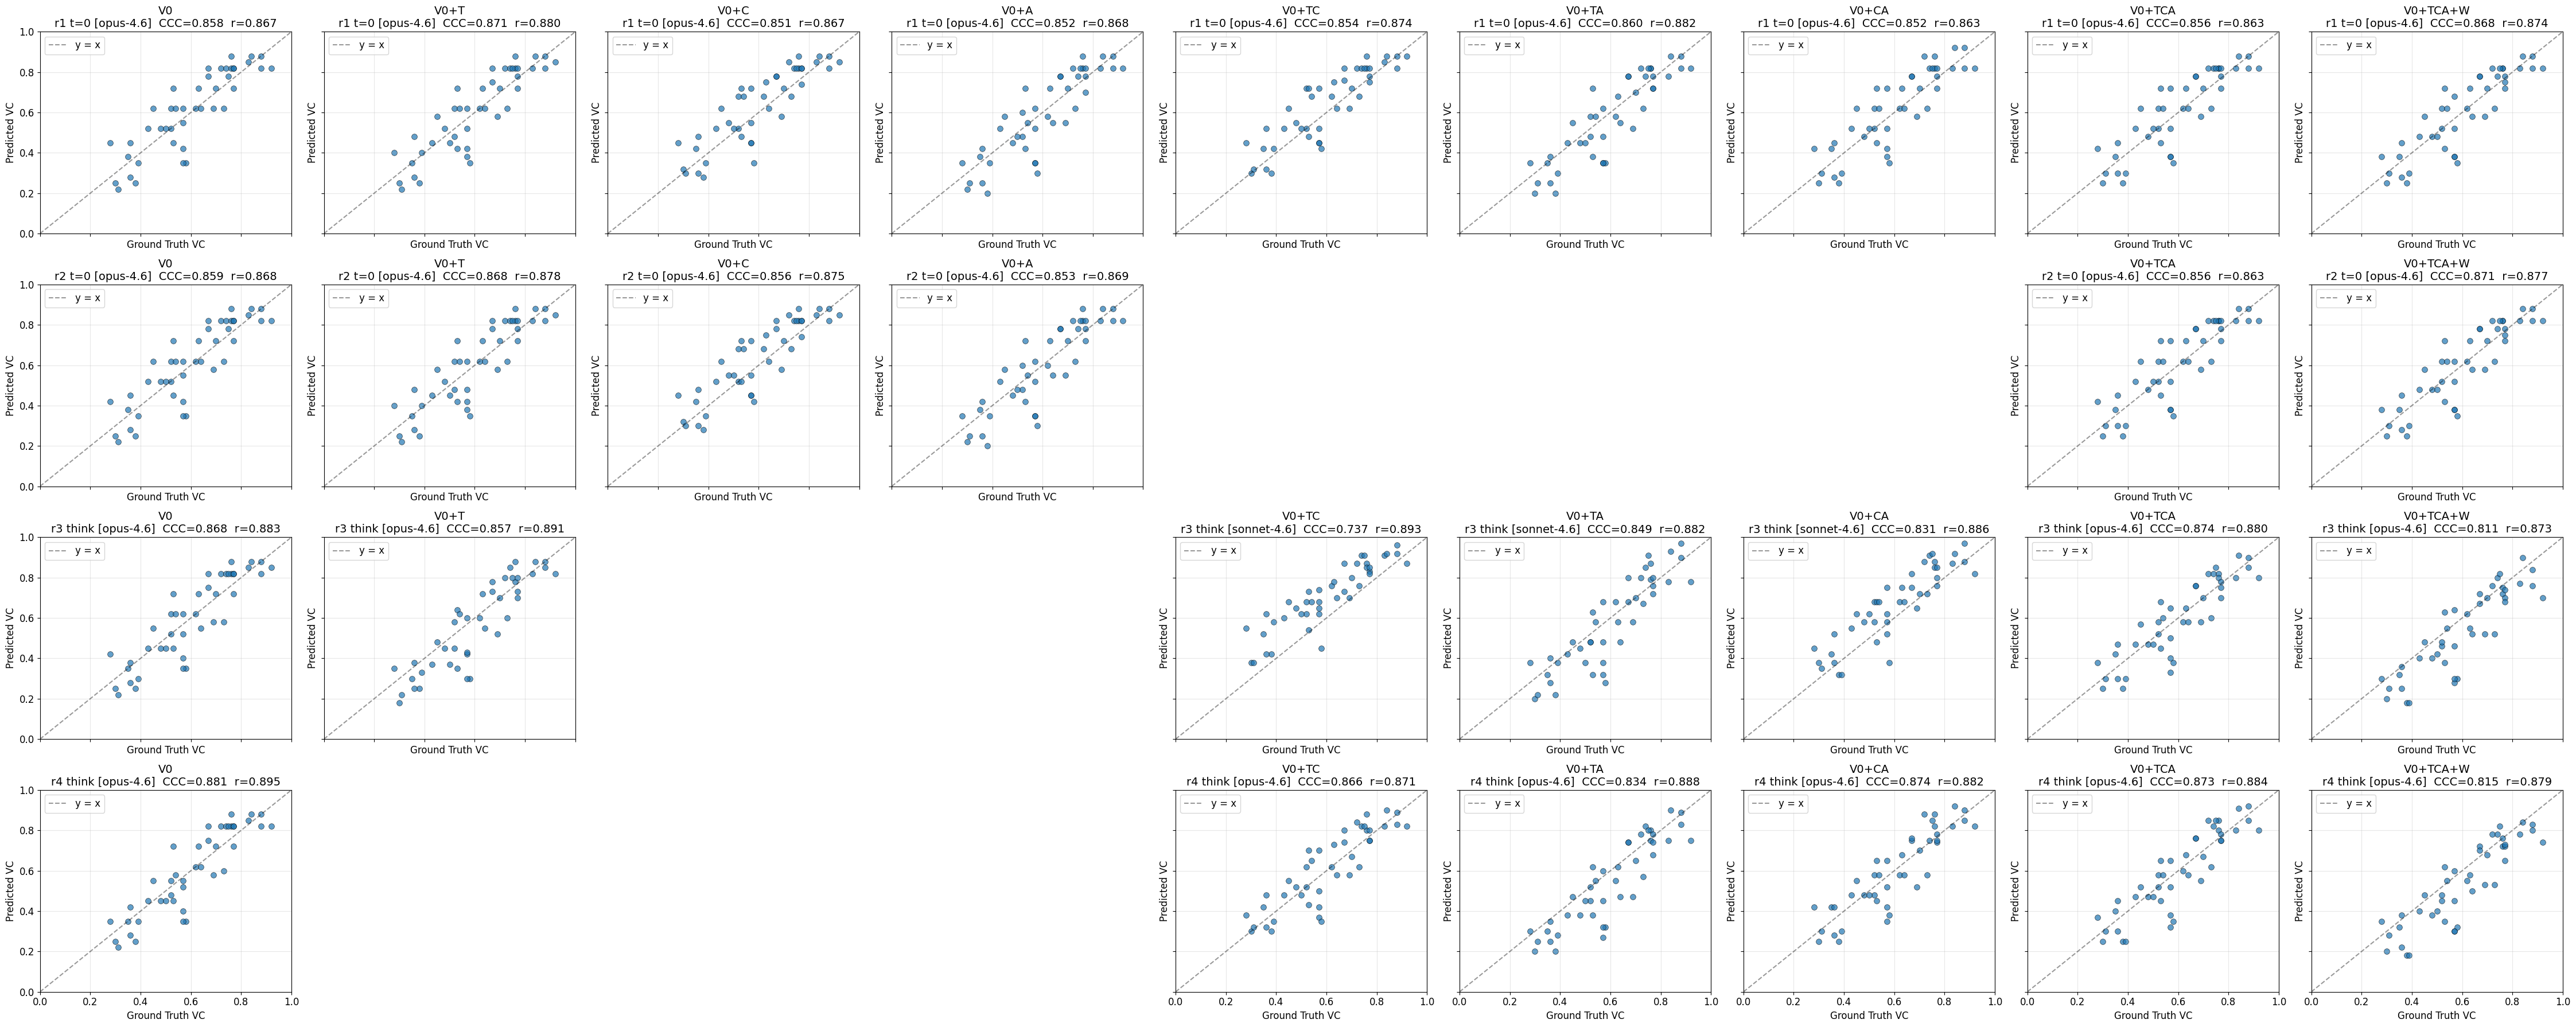

In [68]:
# Scatter plots: one row per run, one column per variant
available_runs = [r for r in RUNS if any(n in merged_by_run[r].columns for n in VARIANT_BASES)]
variants_to_plot = list(VARIANT_BASES.keys())
nrows, ncols = len(available_runs), len(variants_to_plot)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows),
                         sharex=True, sharey=True, squeeze=False)

for row_idx, run in enumerate(available_runs):
    merged = merged_by_run[run]
    for col_idx, name in enumerate(variants_to_plot):
        ax = axes[row_idx][col_idx]
        if name not in merged.columns:
            ax.set_visible(False)
            continue
        sub = merged[['gt', name]].dropna()
        ax.scatter(sub['gt'], sub[name], alpha=0.7, s=50, edgecolor='k', linewidth=0.5)
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='y = x')

        mode = 't=0' if run in ('r1', 'r2') else 'think'
        model = get_run_model(run, name)
        run_label = f'{run} {mode} [{model}]'

        key = (name, run)
        if key in stats_all.index:
            ccc_val = stats_all.loc[key, 'CCC']
            r_val   = stats_all.loc[key, 'Pearson']
            ax.set_title(f'{name}\n{run_label}  CCC={ccc_val:.3f}  r={r_val:.3f}', fontsize=14)
        else:
            ax.set_title(f'{name}\n{run_label} — no data', fontsize=14)

        ax.set_xlabel('Ground Truth VC', fontsize=12)
        ax.set_ylabel('Predicted VC', fontsize=12)
        ax.tick_params(labelsize=12)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)
        ax.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.savefig('v0_variants_scatter.png', dpi=200, bbox_inches='tight')
plt.show()


---

## Full 510-Image Evaluation — V0+TW (Opus-4.6, t=0)

The ablation tables above are computed on the 43-image pilot subset. Here we extend the **V0+TW** variant — second-best in deterministic VC prediction and the best in topic selection — to the **full 510-image set** (520 catalog images minus 10 from rare types: Schematic, Bar-and-point, Table, Area-and-Text). The 46 pilot scores are reused; the remaining 464 images were scored with `claude-opus-4-6`, `temperature=0`, concurrency=5, using `scripts/_vc_score_api_v0_topic_weighted.py`.

Ground truth (`NormalizedVC`) is available for **all 510 images** in `phrase_reduction_v2/image_compiled_phrases.csv`.

In [5]:
# Load full 510-image V0+TW results and merge with full ground truth + VisType
NINE_TYPES = ['Bar', 'Area', 'Glyph', 'Grid', 'Node-link',
              'Cont.-ColorPatn', 'Point', 'Text', 'Line']

scores_510 = pd.read_csv(ROOT / 'results' / 'vc_api_510_v0_tw' / 'vc_scores.csv')
input_510  = pd.read_csv(ROOT / 'results' / 'vc_api_510_v0_tw_input.csv')
gt_full    = pd.read_csv(ROOT / 'phrase_reduction_v2' / 'image_compiled_phrases.csv',
                         usecols=['imageName', 'NormalizedVC']).dropna()

df510 = (scores_510
         .merge(input_510[['imageName', 'VisType']],
                left_on='filename', right_on='imageName', how='left')
         .merge(gt_full.rename(columns={'imageName': 'filename',
                                        'NormalizedVC': 'gt'}),
                on='filename', how='left')
         .dropna(subset=['gt', 'VisType'])
         .reset_index(drop=True))

print(f'Full set N={len(df510)}  '
      f"GT mean={df510['gt'].mean():.3f} std={df510['gt'].std():.3f}  "
      f"Pred mean={df510['vc_score'].mean():.3f} std={df510['vc_score'].std():.3f}")
print('VisType counts:')
print(df510['VisType'].value_counts().reindex(NINE_TYPES).to_string())

Full set N=510  GT mean=0.598 std=0.148  Pred mean=0.568 std=0.201
VisType counts:
VisType
Bar                51
Area               65
Glyph              64
Grid               65
Node-link          66
Cont.-ColorPatn    42
Point              58
Text               51
Line               48


In [6]:
# Compute CCC + diagnostics — overall and per VisType
def _metric_row(label, y, yhat):
    y = np.asarray(y, float); yhat = np.asarray(yhat, float)
    n = len(y)
    return {
        'group':     label,
        'n':         n,
        'CCC':       concordance_cc(y, yhat),
        'Pearson':   pearsonr(y, yhat)[0]   if n >= 2 else np.nan,
        'Spearman':  spearmanr(y, yhat)[0]  if n >= 2 else np.nan,
        'R2':        r2_score(y, yhat)      if n >= 2 else np.nan,
        'MAE':       mean_absolute_error(y, yhat),
        'RMSE':      np.sqrt(mean_squared_error(y, yhat)),
        'mean_pred': yhat.mean(),
        'std_pred':  yhat.std(),
        'mean_gt':   y.mean(),
        'std_gt':    y.std(),
    }

# Overall + pilot subsets for parity with the ablation tables above
pilot46 = df510[df510['filename'].isin(set(pd.read_csv(GT_CSV)['imageName']))]
pilot43 = pilot46[~pilot46['filename'].isin(ANCHOR_IMAGES)]

overall_510 = pd.DataFrame([
    _metric_row(f'ALL (n={len(df510)})',  df510['gt'],  df510['vc_score']),
    _metric_row(f'PILOT (n={len(pilot46)})', pilot46['gt'], pilot46['vc_score']),
    _metric_row(f'PILOT-NO-ANCHORS (n={len(pilot43)})',
                pilot43['gt'], pilot43['vc_score']),
]).round(4)
print('=== Overall ===')
print(overall_510.to_string(index=False))

# Per VisType
vt_510 = pd.DataFrame([
    _metric_row(vt, df510[df510['VisType']==vt]['gt'],
                    df510[df510['VisType']==vt]['vc_score'])
    for vt in NINE_TYPES if (df510['VisType']==vt).any()
]).round(4)
print('\n=== Per VisType ===')
print(vt_510.to_string(index=False))

# Save
out510 = ROOT / 'results' / 'vc_api_510_v0_tw'
overall_510.to_csv(out510 / 'metrics_overall.csv',  index=False)
vt_510.to_csv(out510     / 'metrics_by_vistype.csv', index=False)

=== Overall ===
                  group   n    CCC  Pearson  Spearman     R2    MAE   RMSE  mean_pred  std_pred  mean_gt  std_gt
            ALL (n=510) 510 0.7862   0.8354    0.8338 0.3813 0.0935 0.1162     0.5681    0.2012   0.5976  0.1478
           PILOT (n=46)  46 0.8786   0.8919    0.8865 0.7074 0.0841 0.0988     0.5933    0.2168   0.5987  0.1827
PILOT-NO-ANCHORS (n=43)  43 0.8715   0.8902    0.8839 0.6776 0.0821 0.0974     0.5963    0.2106   0.6007  0.1715

=== Per VisType ===
          group  n    CCC  Pearson  Spearman      R2    MAE   RMSE  mean_pred  std_pred  mean_gt  std_gt
            Bar 51 0.8302   0.8843    0.8792  0.5388 0.0914 0.1079     0.4439    0.2025   0.4918  0.1588
           Area 65 0.8334   0.8750    0.8604  0.5272 0.0797 0.0964     0.5745    0.1894   0.5895  0.1402
          Glyph 64 0.7289   0.8148    0.7852  0.0617 0.1017 0.1290     0.5973    0.2061   0.6312  0.1331
           Grid 65 0.7433   0.7831    0.7641  0.3129 0.0972 0.1172     0.6157    0.1796   0

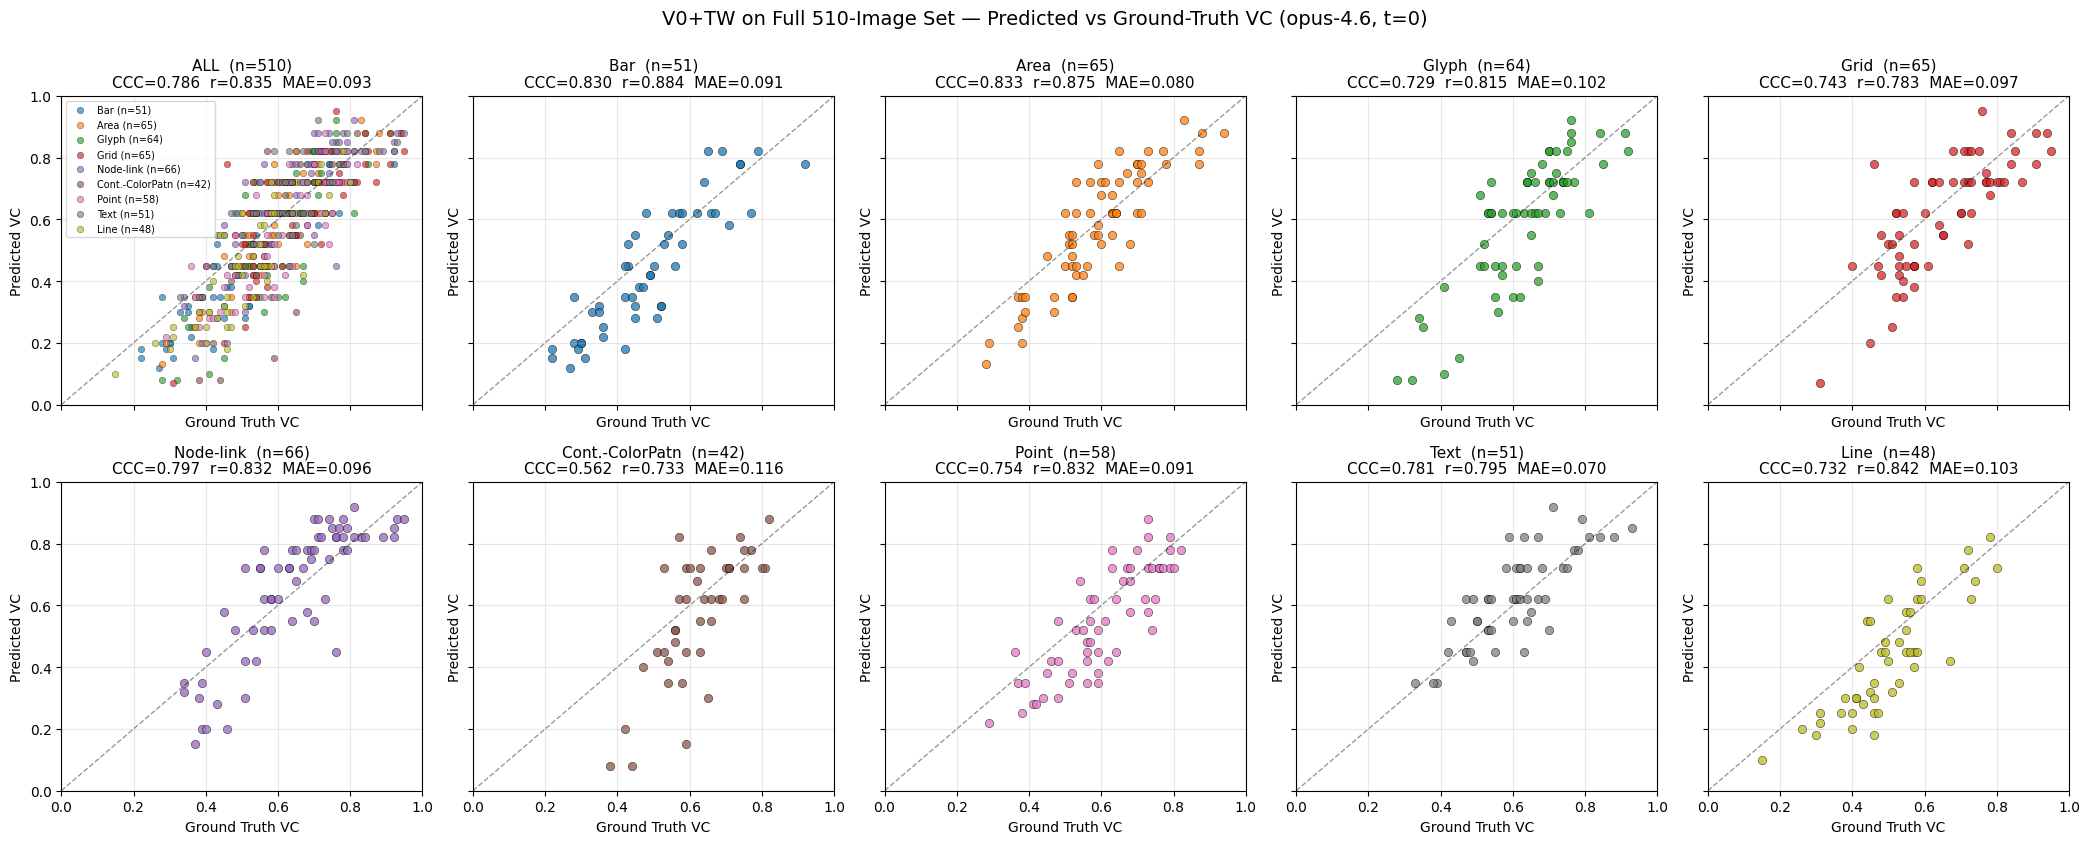

In [7]:
# Scatter plots: ALL + one panel per VisType. Identity line for reference; CCC + r + MAE in title.
palette = dict(zip(NINE_TYPES, plt.cm.tab10.colors[:len(NINE_TYPES)]))
panels = ['ALL'] + NINE_TYPES   # 1 + 9 = 10 panels
ncols = 5
nrows = int(np.ceil(len(panels) / ncols))

# Build a quick lookup of metrics by group label
all_metrics = pd.concat([overall_510.iloc[[0]], vt_510]).set_index('group')
all_label = next(g for g in all_metrics.index if g.startswith('ALL'))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.2 * nrows),
                         sharex=True, sharey=True, squeeze=False)

for idx, panel in enumerate(panels):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]

    if panel == 'ALL':
        for vt in NINE_TYPES:
            s = df510[df510['VisType'] == vt]
            ax.scatter(s['gt'], s['vc_score'], alpha=0.65, s=22,
                       color=palette[vt], edgecolor='k', linewidth=0.3,
                       label=f'{vt} (n={len(s)})')
        ax.legend(loc='upper left', fontsize=7, frameon=True)
        m = all_metrics.loc[all_label]
        title = f'ALL  (n={int(m["n"])})'
    else:
        sub = df510[df510['VisType'] == panel]
        ax.scatter(sub['gt'], sub['vc_score'], alpha=0.75, s=36,
                   color=palette[panel], edgecolor='k', linewidth=0.4)
        m = all_metrics.loc[panel]
        title = f'{panel}  (n={int(m["n"])})'

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, linewidth=1)
    ax.set_title(f'{title}\nCCC={m["CCC"]:.3f}  r={m["Pearson"]:.3f}  '
                 f'MAE={m["MAE"]:.3f}', fontsize=11)
    ax.set_xlabel('Ground Truth VC', fontsize=10)
    ax.set_ylabel('Predicted VC',    fontsize=10)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

# Hide any unused axes
for idx in range(len(panels), nrows * ncols):
    r, c = divmod(idx, ncols)
    axes[r][c].set_visible(False)

fig.suptitle('V0+TW on Full 510-Image Set — Predicted vs Ground-Truth VC '
             '(opus-4.6, t=0)', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig('v0_tw_510_scatter.png', dpi=200, bbox_inches='tight')
plt.show()

### Observations — Full 510 vs. Pilot 43

- **CCC drops from 0.872 (pilot, n=43) to 0.786 (full, n=510)** while Pearson barely moves (0.890 → 0.835). The pilot was sampled to maximize $|\Delta\mathrm{VC}|$ coverage, giving a wider GT spread that inflates CCC; the full set includes many mid-range images where small residuals cost more.
- **Predictions are slightly under-centered and over-spread**: pred mean 0.568 vs. GT mean 0.598; pred std 0.201 vs. GT std 0.148. The model uses more of the 0–1 range than humans do.
- **Best per-type CCC**: Bar (0.830), Area (0.833), Node-link (0.797), Text (0.781) — common chart types where the model's prior matches humans.
- **Weakest per-type CCC**: Cont.-ColorPatn (0.562) — humans rate this type tightly (GT std 0.105) but the model spreads it widely (pred std 0.201), driving R² negative.
- **Systematic under-prediction by ≥ 0.05**: Bar, Line, Cont.-ColorPatn, Point. The model treats "low-clutter" types as lower-VC than humans do.

---

## Earlier Production Run — "V3" Prompt (later renamed V1)

The first production scoring of all 520 images used what was then called the **V3 prompt** (`scripts/_vc_score_api_v3.py`); this prompt was later renamed **V1** in the project's prompt-version history (the "V1" in `vc_api_46gt_v1` directories is the same prompt design). Conceptually it is **V0 + Topics + Calibration + Anchors + Weighted** (≈ V0+TWCA in the ablation), with the additional requirement that the model emit all 7 sub-dimension scores in JSON before producing the holistic `vc_score`. The 7 dimensions are exactly the topics from the T component (`data_density, visual_encoding, text_annotation, domain_schema, color_symbol, aesthetic_order, cognitive_load`).

**Run conditions (re-run for clean ablation).** The original 520-image production run was at the script's default temperature (`TEMPERATURE = None` → API default **t=1, stochastic**), which confounded the prompt comparison with a temperature confound. To isolate the prompt effect, the same V3 prompt was re-scored on the **same 510-image set at t=0** using `scripts/run_v3_510_t0.bat` (results in `results/vc_api_510_v3_t0/`). The V3 vs V0+TW comparison below now holds **model and temperature constant**, varying only the prompt machinery:

|              | V0+TW         | V3 (re-run)   |
|--------------|---------------|---------------|
| Prompt       | T + Weighted  | T + W + C + A + per-dim JSON |
| Model        | claude-opus-4-6 | claude-opus-4-6 |
| Temperature  | 0 (deterministic) | 0 (deterministic) |
| Input set    | 510 images    | 510 images    |

In [14]:
# Load V3 production scores (re-run at t=0 for clean prompt ablation)
v3_scores = pd.read_csv(ROOT / 'results' / 'vc_api_510_v3_t0' / 'vc_scores.csv')
EXCLUDE_VT = {'Schematic', 'Bar and point', 'Table', 'Area and Text'}

# Reuse the same input_510 (which already excludes the rare types) so vis-type
# membership and image set are identical to the V0+TW analysis above.
df510_v3 = (v3_scores[['filename', 'vc_score']]
            .merge(input_510[['imageName', 'VisType']],
                   left_on='filename', right_on='imageName', how='inner')
            .merge(gt_full.rename(columns={'imageName': 'filename',
                                           'NormalizedVC': 'gt'}),
                   on='filename', how='left')
            .dropna(subset=['gt', 'VisType'])
            .reset_index(drop=True))

print(f'V3 set N={len(df510_v3)}  '
      f"GT mean={df510_v3['gt'].mean():.3f} std={df510_v3['gt'].std():.3f}  "
      f"Pred mean={df510_v3['vc_score'].mean():.3f} std={df510_v3['vc_score'].std():.3f}")

overall_v3 = pd.DataFrame([
    _metric_row(f'V3 ALL (n={len(df510_v3)})', df510_v3['gt'], df510_v3['vc_score']),
]).round(4)

vt_v3 = pd.DataFrame([
    _metric_row(vt, df510_v3[df510_v3['VisType']==vt]['gt'],
                    df510_v3[df510_v3['VisType']==vt]['vc_score'])
    for vt in NINE_TYPES if (df510_v3['VisType']==vt).any()
]).round(4)

print('\n=== V3 Overall ===')
print(overall_v3.to_string(index=False))
print('\n=== V3 Per VisType ===')
print(vt_v3.to_string(index=False))

V3 set N=510  GT mean=0.598 std=0.148  Pred mean=0.535 std=0.183

=== V3 Overall ===
         group   n    CCC  Pearson  Spearman     R2    MAE   RMSE  mean_pred  std_pred  mean_gt  std_gt
V3 ALL (n=510) 510 0.7801   0.8556    0.8522 0.4018 0.0931 0.1143     0.5345    0.1832   0.5976  0.1478

=== V3 Per VisType ===
          group  n    CCC  Pearson  Spearman      R2    MAE   RMSE  mean_pred  std_pred  mean_gt  std_gt
            Bar 51 0.7934   0.8960    0.8929  0.4765 0.0967 0.1149     0.4084    0.1782   0.4918  0.1588
           Area 65 0.8255   0.8915    0.8697  0.5191 0.0834 0.0972     0.5394    0.1789   0.5895  0.1402
          Glyph 64 0.7188   0.8080    0.7583  0.1016 0.1014 0.1262     0.5755    0.1892   0.6312  0.1331
           Grid 65 0.7434   0.8157    0.7905  0.3187 0.0985 0.1167     0.5892    0.1710   0.6511  0.1414
      Node-link 66 0.8179   0.8467    0.8423  0.5549 0.0805 0.1037     0.6085    0.1835   0.6435  0.1554
Cont.-ColorPatn 42 0.6138   0.7682    0.7365 -0.5399 

In [15]:
# Side-by-side V0+TW vs V3 — overall + per VisType
def _row(prompt, label, y, yhat):
    r = _metric_row(label, y, yhat); r['prompt'] = prompt; return r

rows = []
rows.append(_row('V0+TW', 'ALL',  df510['gt'],    df510['vc_score']))
rows.append(_row('V3',    'ALL',  df510_v3['gt'], df510_v3['vc_score']))
for vt in NINE_TYPES:
    a = df510[df510['VisType']==vt]
    b = df510_v3[df510_v3['VisType']==vt]
    if len(a): rows.append(_row('V0+TW', vt, a['gt'], a['vc_score']))
    if len(b): rows.append(_row('V3',    vt, b['gt'], b['vc_score']))

cmp_df = pd.DataFrame(rows)[['prompt', 'group', 'n', 'CCC', 'Pearson',
                             'Spearman', 'R2', 'MAE', 'RMSE',
                             'mean_pred', 'std_pred', 'mean_gt', 'std_gt']].round(4)

# Pivot wide for easy reading: one row per group, columns paired by metric/prompt
wide = (cmp_df.pivot(index='group', columns='prompt',
                     values=['CCC', 'Pearson', 'R2', 'MAE'])
              .reindex(['ALL'] + NINE_TYPES))
wide.columns = [f'{m}_{p}' for m, p in wide.columns]
wide = wide[['CCC_V0+TW', 'CCC_V3',
             'Pearson_V0+TW', 'Pearson_V3',
             'R2_V0+TW', 'R2_V3',
             'MAE_V0+TW', 'MAE_V3']].round(4)

# Add deltas (V3 − V0+TW) — positive = V3 better for CCC/Pearson/R2; negative = V3 better for MAE
wide['ΔCCC']     = (wide['CCC_V3']     - wide['CCC_V0+TW']).round(4)
wide['ΔPearson'] = (wide['Pearson_V3'] - wide['Pearson_V0+TW']).round(4)
wide['ΔR2']      = (wide['R2_V3']      - wide['R2_V0+TW']).round(4)
wide['ΔMAE']     = (wide['MAE_V3']     - wide['MAE_V0+TW']).round(4)

print('=== V0+TW vs V3 — same 510-image set, opus-4.6 t=0 ===')
print(wide.to_string())

# Save
out510 = ROOT / 'results' / 'vc_api_510_v0_tw'
cmp_df.to_csv(out510 / 'metrics_v3_vs_v0tw_long.csv',  index=False)
wide.to_csv(  out510 / 'metrics_v3_vs_v0tw_wide.csv')

=== V0+TW vs V3 — same 510-image set, opus-4.6 t=0 ===
                 CCC_V0+TW  CCC_V3  Pearson_V0+TW  Pearson_V3  R2_V0+TW   R2_V3  MAE_V0+TW  MAE_V3    ΔCCC  ΔPearson     ΔR2    ΔMAE
group                                                                                                                               
ALL                 0.7862  0.7801         0.8354      0.8556    0.3813  0.4018     0.0935  0.0931 -0.0061    0.0202  0.0205 -0.0004
Bar                 0.8302  0.7934         0.8843      0.8960    0.5388  0.4765     0.0914  0.0967 -0.0368    0.0117 -0.0623  0.0053
Area                0.8334  0.8255         0.8750      0.8915    0.5272  0.5191     0.0797  0.0834 -0.0079    0.0165 -0.0081  0.0037
Glyph               0.7289  0.7188         0.8148      0.8080    0.0617  0.1016     0.1017  0.1014 -0.0101   -0.0068  0.0399 -0.0003
Grid                0.7433  0.7434         0.7831      0.8157    0.3129  0.3187     0.0972  0.0985  0.0001    0.0326  0.0058  0.0013
Node-link     

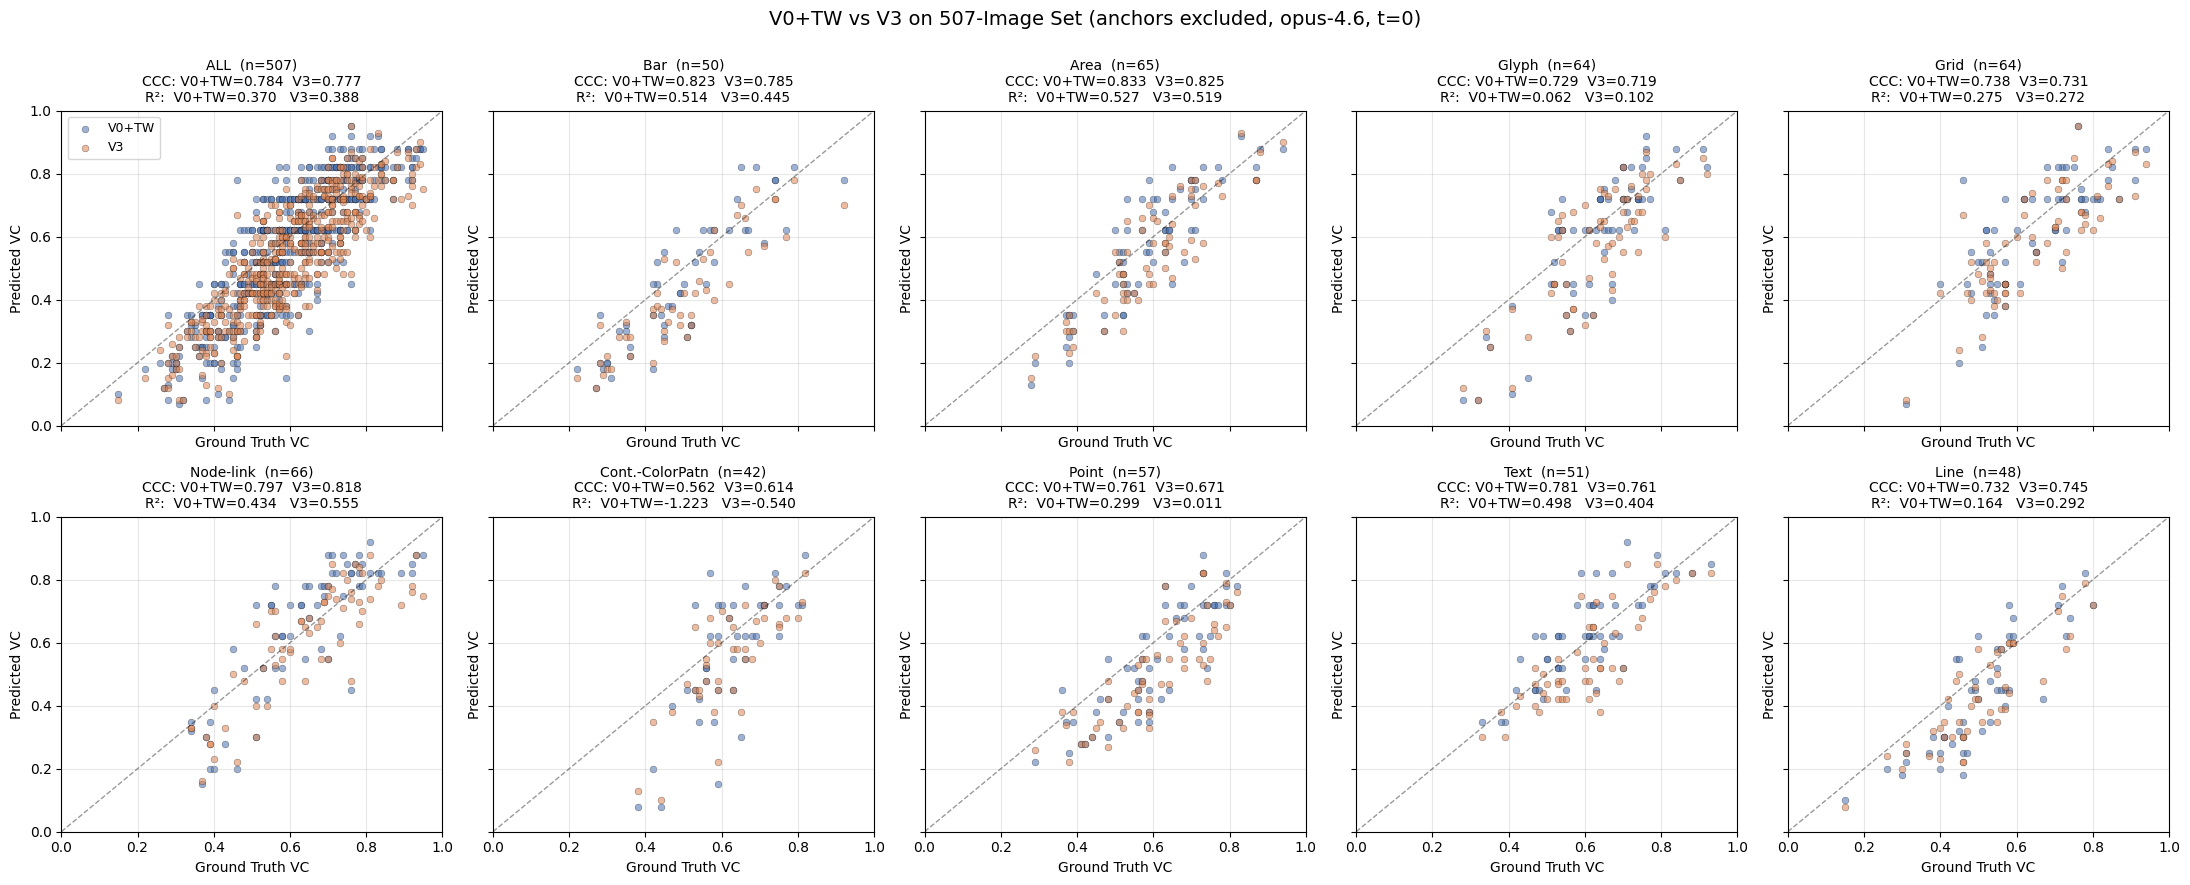

Saved: v0tw_vs_v3_scatter.pdf  (507 images)


In [19]:

# Scatter overlay: V0+TW vs V3 — ALL + per VisType
# Exclude the 3 anchor images (used as few-shot in V3) for a fair comparison → 507 images
df510_plot    = df510[~df510['filename'].isin(ANCHOR_IMAGES)].reset_index(drop=True)
df510_v3_plot = df510_v3[~df510_v3['filename'].isin(ANCHOR_IMAGES)].reset_index(drop=True)

# Recompute metrics on the 507-image set for panel titles
def _cmp_row(prompt, label, y, yhat):
    row = _metric_row(label, y, yhat); row['prompt'] = prompt; return row

rows_507 = []
rows_507.append(_cmp_row('V0+TW', 'ALL', df510_plot['gt'],    df510_plot['vc_score']))
rows_507.append(_cmp_row('V3',    'ALL', df510_v3_plot['gt'], df510_v3_plot['vc_score']))
for vt in NINE_TYPES:
    a = df510_plot[df510_plot['VisType'] == vt]
    b = df510_v3_plot[df510_v3_plot['VisType'] == vt]
    if len(a): rows_507.append(_cmp_row('V0+TW', vt, a['gt'], a['vc_score']))
    if len(b): rows_507.append(_cmp_row('V3',    vt, b['gt'], b['vc_score']))

cmp507 = pd.DataFrame(rows_507).set_index(['prompt', 'group'])

panels = ['ALL'] + NINE_TYPES
ncols = 5
nrows = int(np.ceil(len(panels) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 4.4 * nrows),
                         sharex=True, sharey=True, squeeze=False)

for idx, panel in enumerate(panels):
    r, c = divmod(idx, ncols); ax = axes[r][c]
    if panel == 'ALL':
        a, b = df510_plot, df510_v3_plot
    else:
        a = df510_plot[df510_plot['VisType'] == panel]
        b = df510_v3_plot[df510_v3_plot['VisType'] == panel]
    ax.scatter(a['gt'], a['vc_score'], alpha=0.55, s=24,
               color='#4C72B0', edgecolor='k', linewidth=0.3, label='V0+TW')
    ax.scatter(b['gt'], b['vc_score'], alpha=0.55, s=24,
               color='#DD8452', edgecolor='k', linewidth=0.3, label='V3')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, linewidth=1)

    ccc_a = cmp507.loc[('V0+TW', panel), 'CCC']
    ccc_b = cmp507.loc[('V3',    panel), 'CCC']
    r2_a  = cmp507.loc[('V0+TW', panel), 'R2']
    r2_b  = cmp507.loc[('V3',    panel), 'R2']
    n_a   = int(cmp507.loc[('V0+TW', panel), 'n'])
    ax.set_title(f'{panel}  (n={n_a})\n'
                 f'CCC: V0+TW={ccc_a:.3f}  V3={ccc_b:.3f}\n'
                 f'R²:  V0+TW={r2_a:.3f}   V3={r2_b:.3f}', fontsize=10)
    ax.set_xlabel('Ground Truth VC', fontsize=10)
    ax.set_ylabel('Predicted VC',    fontsize=10)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    if idx == 0:
        ax.legend(loc='upper left', fontsize=9, frameon=True)

for idx in range(len(panels), nrows * ncols):
    r, c = divmod(idx, ncols); axes[r][c].set_visible(False)

fig.suptitle(f'V0+TW vs V3 on {len(df510_plot)}-Image Set (anchors excluded, opus-4.6, t=0)',
             fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig('v0tw_vs_v3_scatter.pdf', bbox_inches='tight')
plt.show()
print(f'Saved: v0tw_vs_v3_scatter.pdf  ({len(df510_plot)} images)')


### Observations — V0+TW vs V3, both opus-4.6 at t=0, same 510-image set

**Headline:** with model and temperature held constant, the two prompts perform almost identically overall (CCC 0.786 vs 0.780, ΔCCC = −0.006). The extra V3 machinery (Calibration + Anchors + per-dimension JSON) does **not** yield a meaningful agreement improvement over V0+TW.

> **Temperature confound resolved.** V3 was originally run at the API default (t=1, stochastic). Re-running V3 at t=0 on the same 510 images changed the overall metrics by ≤ 0.005 across CCC / Pearson / R² / MAE — i.e., temperature was *not* driving the small V3-vs-V0+TW differences seen earlier. The numbers below are the clean prompt-only comparison.

> **Note on R² — why the numbers look different from `VC_520_Analysis.ipynb`.**
> That notebook reports `R² = Pearson r²` (the squared Pearson correlation, equivalent to the coefficient of determination of an *unconstrained linear regression* of pred on gt). It is bounded in [0, 1] and only measures **linear-correlation strength** — it ignores any mean shift or scale mismatch.
> This notebook reports `R²` via **`sklearn.metrics.r2_score(y_true, y_pred)` = 1 − SS_res/SS_tot**, evaluated against the **identity line y = x** (no fitted regression). It can go **negative** when predictions are biased away from y = x, and it penalizes mean shift and scale mismatch the same way CCC does.
> For V3-t=0 these give very different numbers from the *same* data: **Pearson r² ≈ 0.732** vs **sklearn R² = 0.402**. The gap is exactly the bias + scale penalty (V3 bias = −0.063, pred std 0.183 vs GT std 0.148). Pearson r² answers *"how linearly related are pred and gt?"*; sklearn R² answers *"how close are predictions to the diagonal?"*. We use sklearn R² here because it is conceptually consistent with CCC and MAE/RMSE.

- **V3 has slightly higher Pearson and sklearn R²** (r 0.835 → 0.856, R² 0.381 → 0.402): the prompt's calibration + anchors + per-dimension chain-of-thought give a marginally tighter linear relationship.
- **CCC is essentially unchanged** because V3 pulls predictions inward (pred std 0.183 vs V0+TW's 0.201; GT std 0.148) and is more under-centered (V3 mean 0.535 vs GT 0.598; bias = −0.063, larger than V0+TW's −0.030). Better correlation is offset by worse mean shift, netting near-zero in CCC.
- **MAE is a wash** (0.0935 → 0.0931, Δ = −0.0004).
- **Per-VisType winners are split**: V3 wins on Cont.-ColorPatn (+0.052), Node-link (+0.021), Line (+0.013), Grid (+0.000). V0+TW wins on Point (−0.085), Bar (−0.037), Text (−0.020), Glyph (−0.010), Area (−0.008).
- **Biggest V3 regression is on Point** (CCC 0.754 → 0.669, sklearn R² 0.281 → 0.014): V3's calibration anchors push Point predictions away from the true mid-range cluster.
- **Biggest V3 win is on Cont.-ColorPatn** (CCC 0.562 → 0.614, sklearn R² −1.22 → −0.54): V3 is less catastrophically over-spread on this type, though still poor.
- **Conclusion:** the extra prompt machinery in V3 (Calibration + Anchors + Weighted + per-dimension JSON) does **not** improve agreement with humans on the holistic VC score. Pearson / sklearn-R² gain ~0.02 (better linear ranking), CCC drops ~0.006 (extra under-centering wipes out the correlation gain), MAE is unchanged. The simpler V0+TW prompt is competitive on this 510-image evaluation set.